In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch_geometric.datasets import TUDataset

import torch_geometric.nn as pyg_nn
import torch_geometric.transforms as T
import torch_geometric.utils as pyg_utils

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

In [2]:
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

In [3]:
device

'mps'

In [4]:
dataset = TUDataset(
    root="data/TUDataset",
    name="MUTAG",
    use_node_attr=False,
    transform=T.NormalizeFeatures(),
)

In [5]:
dataset

MUTAG(188)

In [6]:
dir(dataset)

['__add__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_data',
 '_data_list',
 '_download',
 '_indices',
 '_infer_num_classes',
 '_process',
 'cleaned',
 'cleaned_url',
 'collate',
 'copy',
 'cpu',
 'cuda',
 'data',
 'download',
 'force_reload',
 'get',
 'get_summary',
 'has_download',
 'has_process',
 'index_select',
 'indices',
 'len',
 'load',
 'log',
 'name',
 'num_classes',
 'num_edge_attributes',
 'num_edge_features',
 'num_edge_labels',
 'num_features',
 'num_node_attributes',
 'num_node_features',
 'num_

In [7]:
dataset = dataset.shuffle()
n = len(dataset)
n_train = int(0.8 * n)

In [8]:
train_dataset = dataset[:n_train]
test_dataset = dataset[n_train:]

In [9]:
train_dataset

MUTAG(150)

In [52]:
from torch_geometric.loader import DataLoader

print(
    f"Loaded MUTAG. Total graphs: {len(dataset)} | Train: {len(train_dataset)} | Test: {len(test_dataset)}"
)

loader_train = DataLoader(train_dataset, batch_size=64, shuffle=True)
loader_test = DataLoader(test_dataset, batch_size=64, shuffle=False)

Loaded MUTAG. Total graphs: 188 | Train: 150 | Test: 38


In [53]:
for x in loader_train:
    print(x)
    break

DataBatch(edge_index=[2, 2624], x=[1184, 7], edge_attr=[2624, 4], y=[64], batch=[1184], ptr=[65])


In [54]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool


class ManualBatchGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, data):
        # Unpack variables directly from the PyG Batch object
        x, edge_index, batch_tensor = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        x = global_mean_pool(x, batch_tensor)
        logits = self.lin(x)
        return logits

In [55]:
first_graph = dataset[0]
print("\n--- First Graph Details ---")
print(f"Number of nodes: {first_graph.num_nodes}")
print(f"Number of edges: {first_graph.num_edges}")
print(f"Has isolated nodes: {first_graph.has_isolated_nodes()}")
print(f"Has self-loops: {first_graph.has_self_loops()}")
print(f"Is undirected: {first_graph.is_undirected()}")


--- First Graph Details ---
Number of nodes: 23
Number of edges: 54
Has isolated nodes: False
Has self-loops: False
Is undirected: True


In [56]:
x

DataBatch(edge_index=[2, 2624], x=[1184, 7], edge_attr=[2624, 4], y=[64], batch=[1184], ptr=[65])

In [30]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

C
C
C
C
C
C
C
C
C
C
C
C
C
C
C
C
C
C
C
C
N
O
O


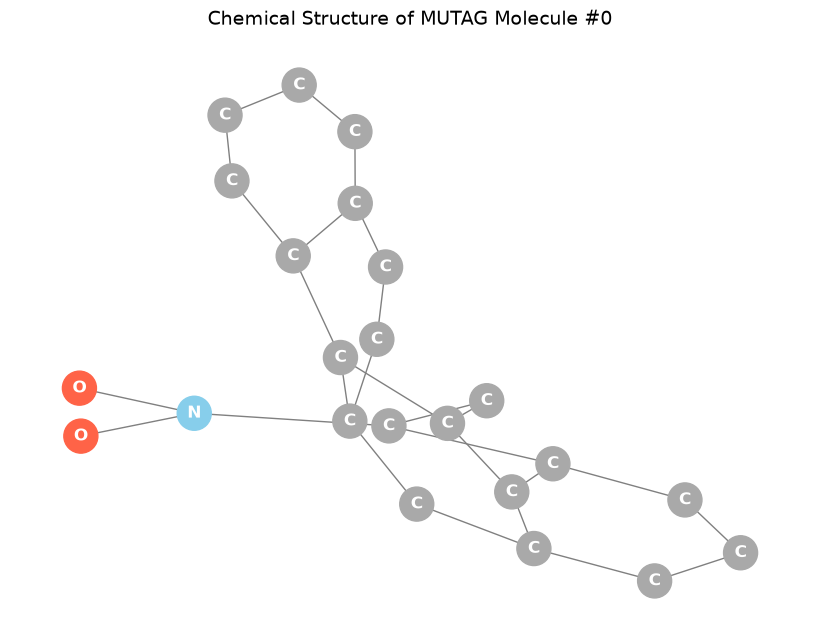

In [39]:
# 3. Convert PyG graph to a NetworkX graph
# We set to_undirected=True since MUTAG represents undirected chemical bonds
molecule = first_graph
g = to_networkx(molecule, to_undirected=True)

# 4. Map node features to atom labels
# MUTAG uses one-hot encoding for atoms: [C, N, O, F, I, Cl, Br]
atom_types = ["C", "N", "O", "F", "I", "Cl", "Br"]
node_labels = {}
node_colors = []

# Color scheme for standard chemical elements
color_map = {
    "C": "darkgray",
    "N": "skyblue",
    "O": "tomato",
    "F": "lightgreen",
    "I": "purple",
    "Cl": "green",
    "Br": "brown",
}

for i in range(molecule.num_nodes):
    # Find the index of the active atom type from the one-hot node features
    atom_idx = molecule.x[i].argmax().item()
    atom_name = atom_types[atom_idx]
    print(atom_name)

    node_labels[i] = atom_name
    node_colors.append(color_map.get(atom_name, "orange"))

# 5. Plot the graph structure
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(g, seed=42)  # Consistent layout positioning

nx.draw(
    g,
    pos,
    labels=node_labels,
    with_labels=True,
    node_color=node_colors,
    node_size=600,
    font_weight="bold",
    font_color="white",
    edge_color="gray",
)

plt.title("Chemical Structure of MUTAG Molecule #0", fontsize=14)
plt.show()

In [48]:
model = ManualBatchGNN(
    in_channels=dataset.num_features,
    hidden_channels=64,
    out_channels=dataset.num_classes,
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

In [36]:
train_dataset.num_features

7

In [38]:
dataset.num_classes

2

In [44]:
# 5. Quick validation check of the first training batch
first_batch = list(iter(loader_train))[1]

print("\n--- First Batch Structure ---")
print(f"Batch object: {first_batch}")
print(f"Number of graphs pooled in this batch: {first_batch.num_graphs}")
print(f"Combined node feature matrix shape [Total Nodes, 7]: {first_batch.x.shape}")
print(f"Batch mapping array size (node to graph tracking): {first_batch.batch.shape}")


--- First Batch Structure ---
Batch object: DataBatch(edge_index=[2, 2576], x=[1162, 7], edge_attr=[2576, 4], y=[64], batch=[1162], ptr=[65])
Number of graphs pooled in this batch: 64
Combined node feature matrix shape [Total Nodes, 7]: torch.Size([1162, 7])
Batch mapping array size (node to graph tracking): torch.Size([1162])


tensor([[1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0.]])

In [49]:
print(model)

ManualBatchGNN(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)


In [62]:
model = ManualBatchGNN(in_channels=7, hidden_channels=64, out_channels=2)

In [63]:
print(model)

ManualBatchGNN(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)


In [68]:
epochs = 150

losses = []
for i in range(1, epochs + 1):
    model.train()
    total_loss = 0
    for batch in loader_train:

        optimizer.zero_grad()

        # Pass the whole object as a single argument
        out = model(batch)

        # Calculate loss against targets
        loss = criterion(out, batch.y)
        losses.append(loss.item())
        total_loss += loss.item() * batch.num_graphs
        loss.backward()
        optimizer.step()
    epoch_loss = total_loss / len(loader_train.dataset)
    # Print progress every 20 epochs to monitor convergence
    if i == 1 or i % 20 == 0:
        print(f"Epoch {i:03d} | Average Loss: {epoch_loss:.4f}")

Epoch 001 | Average Loss: 0.6974
Epoch 020 | Average Loss: 0.6974
Epoch 040 | Average Loss: 0.6974
Epoch 060 | Average Loss: 0.6974
Epoch 080 | Average Loss: 0.6974
Epoch 100 | Average Loss: 0.6974
Epoch 120 | Average Loss: 0.6974
Epoch 140 | Average Loss: 0.6974


In [70]:
min(losses)

0.6930655837059021

In [67]:
len(loader_train.dataset)

150

In [71]:
max(losses)

0.7027437686920166